In [ ]:
from pathlib import Path
import pandas as pd

# Load the file
source_path = Path('/Users/rudolphsurovcik/Library/CloudStorage/OneDrive-Personal/Private Documents/Personal Finance 2026/Tutoring')

# Build the full path to the CSV file
csv_file = source_path / 'Transpose_of_MyStatLab_Data_Set.csv'

# Assign to dataframe
df = pd.read_csv(csv_file, index_col=0)

df.info

# Display the first few rows of the dataframe
print(df.head())		

# run summary statistics on the dataframe
summary_stats = df.describe()

print(summary_stats)

#run correlation analysis on the dataframe
correlation_matrix = df.corr()



In [ ]:
import matplotlib.pyplot as plt

df.hist(bins=10, figsize=(16, 10), grid=False)
plt.tight_layout()
plt.show()


# Calculate the correlation matrix
correlation_matrix = df.corr()
# Extract the correlation values for Customer Satisfaction
customer_satisfaction_corr = correlation_matrix['Customer Satisfaction'].sort_values(ascending=False)
# Display the correlation values
print(customer_satisfaction_corr)



In [ ]:
# Sort the correlation values with respect to Customer Satisfaction
customer_satisfaction_corr = correlation_matrix['Customer Satisfaction'].drop('Customer Satisfaction').sort_values(ascending=False)

print("Variables most strongly correlated with Customer Satisfaction:")
print(customer_satisfaction_corr)

# Key Driver Analysis: Select variables with absolute correlation above a threshold (e.g., 0.9)
threshold = 0.9
key_drivers = customer_satisfaction_corr[customer_satisfaction_corr.abs() > threshold]

print("\nKey Driver Analysis (|correlation| > 0.9):")
print(key_drivers)

# Visualize the key drivers
plt.figure(figsize=(8, 5))
key_drivers.plot(kind='barh', color='skyblue')
plt.title('Key Drivers of Customer Satisfaction')
plt.xlabel('Correlation Coefficient')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()

#Create a scatter plot to visualize the relationship between Customer Satisfaction and the most strongly correlated variable

most_correlated_variable = customer_satisfaction_corr.index[0]
plt.figure(figsize=(8, 5))
plt.scatter(df[most_correlated_variable], df['Customer Satisfaction'], alpha=0.5)
plt.title(f'Customer Satisfaction vs {most_correlated_variable}')

# make the plot more informative by adding labels and a grid

plt.xlabel(most_correlated_variable)
plt.ylabel('Customer Satisfaction')
plt.grid()
plt.tight_layout()
plt.show()



        Customer Satisfaction
Year 1             100.000000
Year 2             100.000000
Year 3              47.117768
Year 4              66.288013
Year 5             100.000000


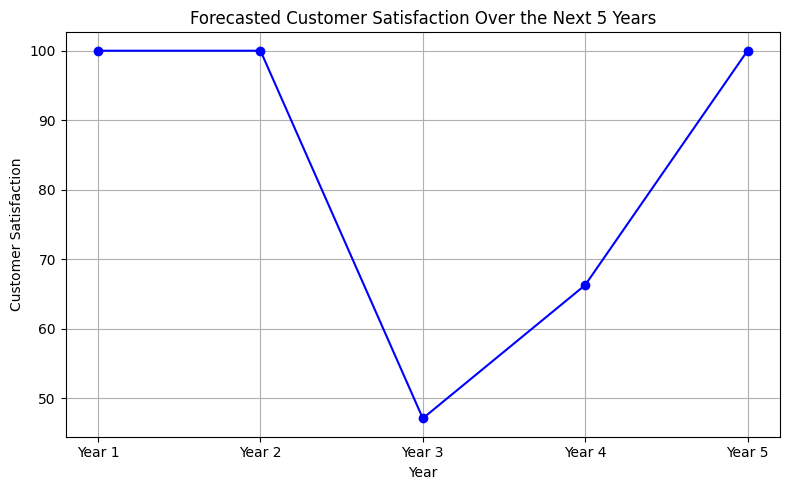

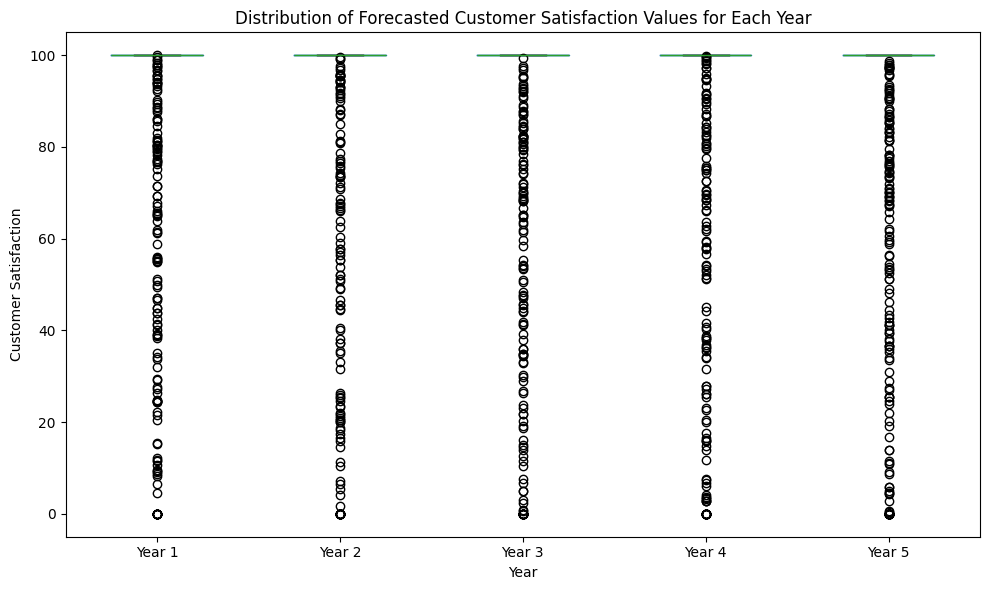

Expected Values for Customer Satisfaction Forecast:
Year 1    93.430421
Year 2    92.925134
Year 3    92.285755
Year 4    92.566950
Year 5    91.111231
dtype: float64

95% Confidence Intervals for Customer Satisfaction Forecast:
           Year 1      Year 2      Year 3      Year 4  Year 5
0.025   12.084996    5.384162    0.752246    2.804489     0.0
0.975  100.000000  100.000000  100.000000  100.000000   100.0

Key Drivers of Forecasted Customer Satisfaction Trends:
Customer Referrals: Average Change Contribution = -4.1656
Order Accuracy: Average Change Contribution = -4.1544
Table Cleanliness: Average Change Contribution = -4.1268
Timeliness of Delivery: Average Change Contribution = -4.1032
Market Share: Average Change Contribution = -4.0417
Total # Complaints: Average Change Contribution = 3.9644
Gross Profit/Seat: Average Change Contribution = -3.9166
Hourly Employee Satisfaction: Average Change Contribution = -3.8939
Revenue Per Employee: Average Change Contribution = -3.8915
Men

In [23]:
import numpy as np
from numpy.__config__ import show

def forecast_customer_satisfaction(df, correlation_matrix, years=5, min_change=-0.03, max_change=0.10, random_state=None):
    """
    Generate a five year forecast of customer satisfaction by changing the variables
    between -3% to +10% change per year.

    Parameters:
        df (pd.DataFrame): Original dataframe with the latest year as the last row.
        correlation_matrix (pd.DataFrame): Correlation matrix for the variables.
        years (int): Number of years to forecast.
        min_change (float): Minimum percent change per year (e.g., -0.03 for -3%).
        max_change (float): Maximum percent change per year (e.g., 0.10 for +10%).
        random_state (int or None): Seed for reproducibility.

    Returns:
        pd.DataFrame: Forecasted values for each year.
    """
    np.random.seed(random_state)
    last_row = df.iloc[-1].copy()
    variables = [col for col in df.columns if col != 'Customer Satisfaction']
    forecast = []

    for i in range(years):
        changes = np.random.uniform(min_change, max_change, size=len(variables))
        new_values = last_row[variables] * (1 + changes)
        # Predict Customer Satisfaction using a weighted sum of changes and correlations
        weights = correlation_matrix.loc[variables, 'Customer Satisfaction'].values
        # Normalize weights to sum to 1 for a weighted average
        norm_weights = np.abs(weights) / np.sum(np.abs(weights))
        cs_pred = (new_values - last_row[variables]).values @ norm_weights + last_row['Customer Satisfaction']
        # Optionally, clip cs_pred to a reasonable range (e.g., 0-100)
        cs_pred = np.clip(cs_pred, 0, 100)
        # Build the forecast row
        row = new_values.to_dict()
        row['Customer Satisfaction'] = cs_pred
        forecast.append(row)
        # Update last_row for next iteration
        last_row = pd.Series(row)

    forecast_df = pd.DataFrame(forecast, index=[f"Year {i+1}" for i in range(years)])
    return forecast_df

# Example usage:
forecast_df = forecast_customer_satisfaction(df, correlation_matrix, years=5, min_change=-0.03, max_change=0.10, random_state=42)
print(forecast_df[['Customer Satisfaction']])

#show the forecasted customer satisfaction over the next five years
plt.figure(figsize=(8, 5))
plt.plot(forecast_df.index, forecast_df['Customer Satisfaction'], marker='o', linestyle='-', color='blue')
plt.title('Forecasted Customer Satisfaction Over the Next 5 Years')
plt.xlabel('Year')
plt.ylabel('Customer Satisfaction')
plt.grid()
plt.tight_layout()
plt.show()  

#redo the forecast but use a monte carlo simulation approach to generate a distribution of possible outcomes for customer satisfaction in each of the next five years, rather than a single forecasted value. This will allow us to understand the range of potential outcomes and the associated probabilities.     

def monte_carlo_forecast(df, correlation_matrix, years=5, min_change=-0.03, max_change=0.10, simulations=1000, random_state=None):
    """
    Generate a Monte Carlo simulation forecast of customer satisfaction for the next five years.

    Parameters:
        df (pd.DataFrame): Original dataframe with the latest year as the last row.
        correlation_matrix (pd.DataFrame): Correlation matrix for the variables.
        years (int): Number of years to forecast.
        min_change (float): Minimum percent change per year (e.g., -0.03 for -3%).
        max_change (float): Maximum percent change per year (e.g., 0.10 for +10%).
        simulations (int): Number of Monte Carlo simulations to run.
        random_state (int or None): Seed for reproducibility.

    Returns:
        pd.DataFrame: DataFrame containing the distribution of forecasted customer satisfaction values for each year.
    """
    np.random.seed(random_state)
    last_row = df.iloc[-1].copy()
    variables = [col for col in df.columns if col != 'Customer Satisfaction']
    all_forecasts = {f"Year {i+1}": [] for i in range(years)}

    for sim in range(simulations):
        current_row = last_row.copy()
        for i in range(years):
            changes = np.random.uniform(min_change, max_change, size=len(variables))
            new_values = current_row[variables] * (1 + changes)
            weights = correlation_matrix.loc[variables, 'Customer Satisfaction'].values
            norm_weights = np.abs(weights) / np.sum(np.abs(weights))
            cs_pred = (new_values - current_row[variables]).values @ norm_weights + current_row['Customer Satisfaction']
            cs_pred = np.clip(cs_pred, 0, 100)
            all_forecasts[f"Year {i+1}"].append(cs_pred)
            current_row[variables] = new_values
            current_row['Customer Satisfaction'] = cs_pred

    forecast_df = pd.DataFrame(all_forecasts)
    return forecast_df

# show the distribution of forecasted customer satisfaction values for each year using box plots

forecast_distribution = monte_carlo_forecast(df, correlation_matrix, years=5, min_change=-0.03, max_change=0.10, simulations=1000, random_state=42)
plt.figure(figsize=(10, 6))
forecast_distribution.boxplot()
plt.title('Distribution of Forecasted Customer Satisfaction Values for Each Year')
plt.xlabel('Year')

#using the monte_carlo_forecast function to generate the distribution of forecasted customer satisfaction values for each year and then visualizing it using box plots to show the range and variability of the forecasts. This will help us understand the potential outcomes and their probabilities over the next five years. 
plt.ylabel('Customer Satisfaction')
plt.grid()
plt.tight_layout()
plt.show()  

# show the expected value and confidence intervals for the forecasted customer satisfaction in each year based on the Monte Carlo simulation results. This will provide insights into the most likely outcomes and the uncertainty associated with the forecasts.
# Calculate expected value and confidence intervals
expected_values = forecast_distribution.mean()  
confidence_intervals = forecast_distribution.quantile([0.025, 0.975])
print("Expected Values for Customer Satisfaction Forecast:")
print(expected_values)
print("\n95% Confidence Intervals for Customer Satisfaction Forecast:")
print(confidence_intervals)

# show key drivers explaining the forecasted customer satisfaction trends over the next five years based on the Monte Carlo simulation results. This will help us understand which variables are most influential in driving changes in customer satisfaction and how they contribute to the forecasted outcomes.
# Calculate the average change in each variable across simulations and years
average_changes = {}
for variable in correlation_matrix.columns:
    if variable != 'Customer Satisfaction':
        changes = []
        for year in forecast_distribution.columns:
            for sim in range(1000):
                change = (forecast_distribution[year][sim] - df['Customer Satisfaction'].iloc[-1]) * correlation_matrix.loc[variable, 'Customer Satisfaction']
                changes.append(change)
        average_changes[variable] = np.mean(changes)
# Sort the average changes to identify key drivers
sorted_drivers = sorted(average_changes.items(), key=lambda x: abs(x[1]), reverse=True)
print("\nKey Drivers of Forecasted Customer Satisfaction Trends:")
for variable, avg_change in sorted_drivers:
    print(f"{variable}: Average Change Contribution = {avg_change:.4f}")



In [ ]:
# Preview the data
df

# Select only numeric columns for correlation
numeric_df = df.select_dtypes(include='number')

correlation_matrix = numeric_df.corr()
correlation_matrix

